### DATA et Data analyse

#### 1 Data

##### 1.1 Import 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tqdm
import seaborn as sns
from sklearn.svm import LinearSVC
from sklearn.feature_selection import mutual_info_classif
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("PartyAnimals.csv", sep = ";")

In [3]:
#extraction des données 
x = df.iloc[:,:-1]
y = df.iloc[:,-1:]

#transformation en matrice numpy 
x = np.array(x)
y = np.array(y)

#dimensions 
print(x.shape, y.shape) # (1137, 19) (1137, 1) 

(1137, 19) (1137, 1)


##### 1.2 Data normalizing

In [5]:
# normalisation des x 
new_x = []
for i in range(len(x[1])):
    maximum_by_column = x[:,i].max()  
    new_column = [(j/ maximum_by_column) for j in x[:,i]]
    new_x.append(new_column)    
x = np.array(new_x).T 
x.shape

(1137, 19)

### 2. Visualization 

##### 2.1 Boxplot 

In [8]:
def box_plot(x):
    # création de deux matrices une pour les cas ou y==1 et l'autre ou y == 2 et comparaison pour chaque feature à l'aide de boxplots.
    matrix_y_1 = np.array([x[i]for i in range(len(x)) if y[i] == 1])
    matrix_y_2 = np.array([x[j] for j in range(len(x))if y[j] == 2])

    plt.figure(figsize = (15,20))
    for i in range(len(x.T)): 
        plt.subplot(5, 4, i+1)
        plt.boxplot((matrix_y_1[:,i], matrix_y_2[:,i]))
        plt.title(f"Feature {i}")
        plt.xlabel("values y")
    plt.suptitle("Boxplot for each feature depending of Y value", fontsize = 30, y =1.01)
    plt.tight_layout()
    plt.show()
    return

##### 2.2 Mean and std by feature 

In [10]:
def mean_std(x):
    mean = [np.mean(x[i]) for i in range(x.shape[1])]
    std = [np.std(x[i]) for i in range(x.shape[1])]

    plt.figure()
    for i in range(x.shape[1]):
        plt.bar(range(len(mean)), mean[i],yerr = std[i] ,linestyle = None, color ="purple")

    plt.xticks(range(len(mean)))
    plt.title("Mean and Standar Deviation for each feature", fontsize = 25, y=1.02)
    plt.show()
    return

##### 2.3 Correlation and covariance matrix

In [12]:
def covariance_correlation_matrix(x):
    covariance_matrix = np.cov(x, rowvar = False)
    plt.figure(figsize=(12,10))
    sns.heatmap(covariance_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("Covariance Heatmap")
    plt.show()

    correlation_matrix = np.corrcoef(x, rowvar = False)
    plt.figure(figsize=(12,10))
    sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("Correlation Heatmap")
    plt.show()
    return covariance_matrix, correlation_matrix

#### 3 Feature weighting 

##### 3.1 Correlation between each feature and Y

In [15]:
def correlation_feature_y(x, y): 
    coef_to_plot = []
    for i in range(len(x.T)):
        coef = np.corrcoef((x.T[i],y[:,0]))
        coef_to_plot.append(coef[1][0])
    return coef_to_plot

In [16]:
##### 3.2 Non-linear relevance between each feature and Y 

In [17]:
def non_linear_relevance(x, y): 
    mi = mutual_info_classif(x, y.flatten()) # le flatten survient après un warning
    return mi 

##### 3.3 Logistique regression 

In [63]:
def model_log(x, theta):
    z = x.dot(theta)
    activation = 1/(1+ np.exp(-z))
    return activation

def log_loss(x, y, theta): # pas sur que ce soit log_loss à vérifier. 
    act = model_log(x,theta)
    epsilon = 1e-15
    act = np.clip(act, epsilon, 1-epsilon)
    cost = (-1/x.shape[0]) * ((y * np.log(act)) + ((1-y)*np.log(1-act))).sum()
    return cost

def gradient(x, y, theta):
    act = model_log(x, theta)
    return (1/x.shape[0]) * x.T.dot(act-y)

def gradient_descent(x, y, theta= np.ones((19,1)), lr=0.01, n_iter=2000):
    cost_history = np.zeros(n_iter)
    for i in range(n_iter):
        grad = gradient(x, y, theta)
        theta = theta - (lr * grad)
        cost_history[i] = log_loss(x, y, theta)
    theta = theta.flatten().tolist()
    return theta, cost_history

# cost, theta = gradient_descent(x, y, np.ones((19,1)), 0.01, 20)


##### 3.4 Artificial Neural network 1 layer 

In [21]:
def initialisation(dimensions):
    
    parameters = {}
    C = len(dimensions)
            
    for c in range(1, C):
        parameters["W" + str(c)] = np.random.randn(dimensions[c],dimensions[c-1])
        parameters["b" + str(c)] = np.random.randn(dimensions[c], 1)
        
    return parameters

def model(x, parameters):
    activations = {}
    activations["A0"] = x.T
    
    C = len(parameters)//2
    
    # modèle :
    for c in range(1,C+1):
        activations["A"+ str(c)] = 1/(1+np.exp(-(parameters["W"+str(c)].dot(activations["A"+str(c-1)])+ parameters["b"+str(c)])))        #+ parameters["b"+str(c)])))
    
    return activations

def back_prop(parameters, activations, y):
    
    m = y.shape[0]
    C = len(parameters)//2
    dZ = activations["A"+str(C)]-y.T
    gradient = {}
    for c in reversed(range(1,C+1)):
        gradient["dW"+str(c)] = 1/m * np.dot(dZ,  activations["A" + str(c-1)].T)
        gradient["db"+str(c)] = 1/m * dZ.sum(axis =1)
        if c > 1:
            dZ = np.dot(parameters["W"+str(c)].T, dZ) * (activations["A" + str(c-1)]*(1-activations["A" + str(c-1)]))
    
    return gradient

def cost_function(x, y, parameters):
    
    activations = model(x, parameters)
    m = y.shape[0]
    C = len(activations) - 1
    
    A = activations["A"+str(C)]
    
    epsilon = 1e-15
    A = np.clip(A, epsilon, 1-epsilon)
    
    cost = -1/m * np.sum(y.T * np.log(A) + (1 - y.T) * np.log(1 - A))
    
    return cost

def grad_descent(x, y, layers, lr=0.01, n_iter=2000):
    parameters = initialisation(layers)
    cost_history = np.zeros(n_iter)
    for i in tqdm.tqdm(range(n_iter)):
        
        activations = model(x,parameters)
        gradient = back_prop(parameters, activations, y)
        
        C = len(parameters)//2

        for c in range(1,C+1):
            parameters["W"+str(c)] = parameters["W"+str(c)] - lr * gradient["dW"+str(c)]
            parameters["b"+str(c)] = parameters["b"+str(c)] - lr * gradient["db"+str(c)]
            cost_history[i] = cost_function(x, y, parameters)
    parameters = parameters["W1"].flatten()
    return parameters, cost_history

##### 3.5 Support Vector Machine 

In [23]:
def svm(x, y):
    pipeline = Pipeline([("scaler", StandardScaler()), ("svm", LinearSVC(dual=True, max_iter=10000))])
    pipeline.fit(x, y.flatten())
    coef = pipeline.named_steps["svm"].coef_
    coef = coef.flatten()
    return coef 

##### 3.6 RandomForest 

In [25]:
def random_forest(x, y):
    model = RandomForestClassifier(n_estimators=200, random_state=0)
    model.fit(x, y)
    importance = model.feature_importances_
    return importance

## KNN algorithm 

### 4 Utilitars

#### 4.1 Distances

In [29]:
def manhattan(x, theta): 
    x = x * theta 
    return np.abs(x[:,None, :] - x[None,:,:]).sum(axis=2)

def euclidean(x, theta):
    x = x * theta
    G = x.dot(x.T)                              # (1137, 1137)  matrice de gram : G = XX.T
    norm = np.sum(x**2, axis = 1)               # (1137,)       norme de la matrice x, la racine saute étant donné que c'est au carré (a² et b²) il reste donc la somme des carré.   
    return norm[None,:] + norm[:,None] - 2 * G 

def minkowski(x, theta, p):
    x = x * theta 
    diff = np.abs(x[:,None,:] - x[None,:,:])
    return np.sum(diff**p, axis =2)**(1/p)

def cosine(x, theta): 
    x = x*theta
    norm = np.sqrt(np.sum(x**2, axis = 1))
    G = x.dot(x.T)
    return 1 - (G / (norm[:,None] * norm[None, :]))
# chebyschev p = 10000

#### 4.2 Votes 

In [31]:
def vote_simple(y, idx, **kwargs): 
    y_nn = y[idx]
    mean_votes = np.mean(y_nn, axis=1)
    return np.mean(y_nn, axis =1)

def vote_distance(y, idx, distance, k, **kwargs):
    dist_nn = np.take_along_axis(distance, idx, axis=1)
    eps = 1e-15
    weights = 1 / (dist_nn + eps)
    y_nn = y[idx]
    vote_1 = np.sum(weights * (y_nn == 1), axis=1) # toute cette partie là se répète on peut en faire une fonction simple
    vote_2 = np.sum(weights * (y_nn == 2), axis=1)
    return np.where(vote_2 > vote_1, 2, 1)

def vote_rank(y, idx, distance, k, **kwargs):
    dist_nn = np.take_along_axis(distance, idx, axis=1)
    order = np.argsort(dist_nn, axis=1)
    idx_sorted = np.take_along_axis(idx, order, axis=1)
    y_nn = y[idx_sorted]
    ranks = np.arange(k, 0, -1)
    vote_1 = np.sum((y_nn == 1) * ranks, axis=1)
    vote_2 = np.sum((y_nn == 2) * ranks, axis=1)
    return np.where(vote_2 > vote_1, 2, 1)

def vote_gaussian(y, idx, distance, k, sigma=1.0, **kwargs):
    dist_nn = np.take_along_axis(distance, idx, axis=1)
    weights = np.exp(-(dist_nn**2) / (2 * sigma**2))
    y_nn = y[idx]
    vote_1 = np.sum(weights * (y_nn == 1), axis=1)
    vote_2 = np.sum(weights * (y_nn == 2), axis=1)
    return np.where(vote_2 > vote_1, 2, 1)


#### 4.3 Dictionnary utilitar 

In [104]:
feature_weighting = {
    "none": lambda x, y, *args, **kwargs: np.ones((1, x.shape[1])),
    "correlation": correlation_feature_y,
    "non_linear": non_linear_relevance,
    "svm" : svm,
    "random_forest" : random_forest
}
distance_functions = {
    "euclidean": euclidean,
    "manhattan": manhattan,
    "minkowski": minkowski,
    "cosine": cosine,
}
vote_functions = {
    "simple": vote_simple,
    "distance": vote_distance,
    "rank": vote_rank,
    "gaussian": vote_gaussian,
}

### 5 Results 

#### 5.1 Descriptive 

In [73]:
def summary_descriptive(x, y): 
    box_plot(x)
    mean_std(x)
    covariance_correlation_matrix(x)
    
    coef_corr_feat = correlation_feature_y(x, y)
    coef_non_lin_rel = non_linear_relevance(x, y)
    coef_logistic, cost_log  = gradient_descent(x, y, np.ones((19,1)), 0.01, 2000)
    coef_ann, cost_ann = grad_descent(x, y, (19,1), 0.01, 2000)
    coef_svm = svm(x, y)
    coef_random_forest = random_forest(x, y)
    
    fig, axes = plt.subplots(3, 2, figsize = (25,20))
    
    
    fig.suptitle("Weighting features",fontsize = 40)

    fig.text(0.5, 0.90, "Based on data", ha="center", fontsize = 25)

    axes[0,0].bar(range(len(coef_corr_feat)), coef_corr_feat)
    axes[0,0].set_title("Correlation", fontsize = 20)
    axes[0,0].set_xticks(range(len(coef_corr_feat)))

    axes[0,1].bar(range(len(coef_non_lin_rel)), coef_non_lin_rel)
    axes[0,1].set_title("Non Linear Relevance", fontsize = 20)
    axes[0,0].set_xticks(range(len(coef_non_lin_rel)))

    fig.text(0.5, 0.62, "Gradient Models", ha="center", fontsize = 25)

    axes[1,0].bar(range(len(coef_logistic)), coef_logistic)
    axes[1,0].set_title("Logistic Regression",fontsize = 20)
    axes[0,0].set_xticks(range(len(coef_logistic)))

    axes[1,1].bar(range(len(coef_ann)), coef_ann)
    axes[1,1].set_title("ANN", fontsize = 20)
    axes[0,0].set_xticks(range(len(coef_ann)))

    fig.text(0.5, 0.35, "Machine Learning Models", ha="center", fontsize = 25)

    axes[2,0].bar(range(len(coef_svm)), coef_svm)
    axes[2,0].set_title("SVM", fontsize = 20)
    axes[0,0].set_xticks(range(len(coef_svm)))

    axes[2,1].bar(range(len(coef_random_forest)), coef_random_forest)
    axes[2,1].set_title("Random Forest",fontsize = 20)
    axes[0,0].set_xticks(range(len(coef_random_forest)))

    plt.tight_layout([1,1,1,1])
    plt.show()
     

#### KNN simple 

('les 5 meilleurs k et leur accuracy sont :',
 [(17, 0.7088830255057168),
  (9, 0.7080035180299032),
  (15, 0.7044854881266491),
  (13, 0.7018469656992085),
  (25, 0.7018469656992085)])

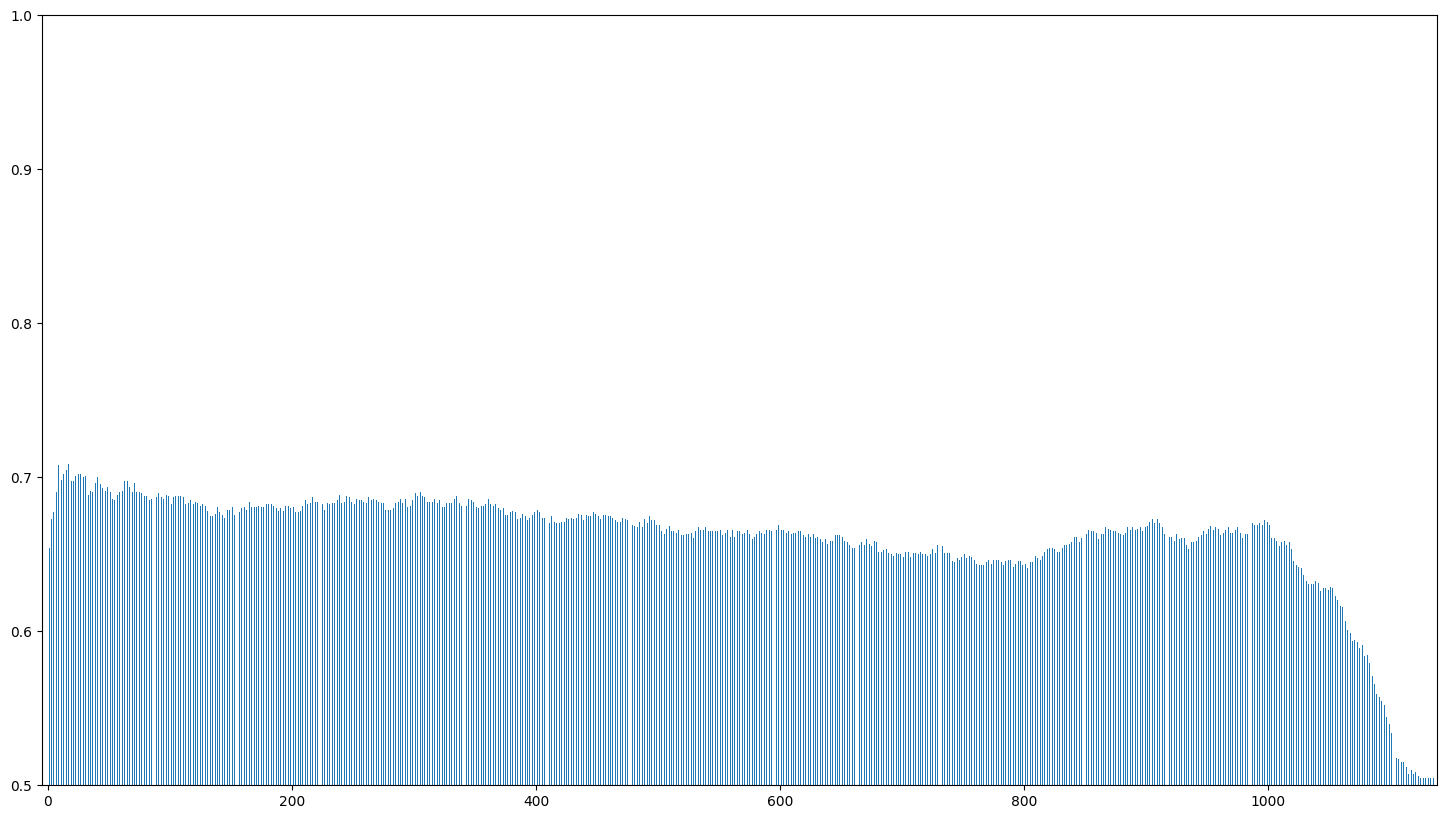

In [76]:
# calculer toutes les distances 
def calculate_all_distances(x, theta):
    x = x * theta
    G = x.dot(x.T)                              
    norm = np.sum(x**2, axis = 1)             
    return norm[None,:] + norm[:,None] - 2 * G  

def leave_one_out( matrice_distances):        
    np.fill_diagonal(matrice_distances, np.inf)    
    return matrice_distances

def extract_idx_NN(X_array, distances_to_sort, k):
    idx = np.argpartition(distances_to_sort, k)[:,:k]
    return idx

def calculate_y_pred(X_array, y, idx, k):
    y_to_mean = y[idx]
    y_meaned_to_classifie = np.mean(y_to_mean, axis = 1)
    y_pred = np.where(y_meaned_to_classifie > 1.5, 2,1)
    return y_pred

def process_accuracy(X_array, y, y_pred, k):
    err = np.sum(y!=y_pred)
    acc = 1 - err / len(y)
    return acc

def KNN(x, y, k, theta):
    matrice_distance = calculate_all_distances(x, theta)
    distances_to_sort = leave_one_out(matrice_distance)
    idx = extract_idx_NN(x, distances_to_sort, k)
    y_pred = calculate_y_pred(x, y, idx, k)
    acc = process_accuracy(x, y, y_pred, k)
    acc = np.float64(acc)
    return acc

def plot_acc_k(x,y, range_k, theta):
    value_to_plot = {} 
    for i in range(range_k):
        if i%2!=0 :
            value_to_plot[i] = KNN(x,y,i, theta)
    
    fig, ax = plt.subplots(1, 1, figsize=(18,10))
    ax.bar(value_to_plot.keys(),list(value_to_plot.values()),)
    ax.set_ylim(0.5,1) # remplacer 0.5 par min_value - 0.1 
    ax.set_xlim(-5,1138)
    perf_sorted = sorted(value_to_plot.items(), key = lambda x : x[1], reverse=True)
    
    return "les 5 meilleurs k et leur accuracy sont :", perf_sorted[:5]

theta= np.ones((1,19))
plot_acc_k(x,y, 1137, theta)

#### KNN with all variations

In [ ]:
def compute_distance(x, theta, distance_function, p=5):
    if distance_function == minkowski:
        distance = distance_function(x, theta, p)
    else:
        distance = distance_function(x, theta)
    np.fill_diagonal(distance, np.inf) # leave one out. 

    return distance

def KNN_from_distance(distance, y, k, vote_function, **vote_kwargs):
    y = y.ravel()
    idx = np.argpartition(distance, k, axis=1)[:, :k]
    y_pred = vote_function(y=y, idx=idx, distance=distance, k=k, **vote_kwargs)
    acc = np.mean(y_pred == y)
    return acc

def run_full_experiment(x, y, range_k):
    results = []
    for fw_name, fw_func in feature_weighting.items():
        
        if isinstance(results, tuple):
            theta = results[0]
        else:
            theta = results
            
        if fw_name in ["gradient_descent", "grad_descent"]:
            _, theta = fw_func(x, y, np.ones((19,1)), 0.01, 2000)
        else:
            theta = fw_func(x, y)
        for dist_name, dist_func in distance_functions.items():
            distance = compute_distance(x, theta, dist_func)
            for vote_name, vote_func in vote_functions.items():
                acc_list = []
                for k in range(1, range_k, 2):
                    acc = KNN_from_distance(distance, y, k, vote_func, sigma=2)  # only used if gaussian)
                    acc_list.append(acc)
                results.append({
                "feature_weight": fw_name,
                "distance": dist_name,
                "vote": vote_name,
                "accuracy_list": acc_list,
                "best_acc": max(acc_list),
                "best_k": (2 * np.argmax(acc_list) + 1),
                "theta": theta
            })

    return results
    

def plot_best_setup_simple(results, range_k):

    best = max(results, key=lambda x: x["best_acc"])

    
    k_values = list(range(1, len(best["accuracy_list"]) * 2, 2))

    plt.figure(figsize=(8, 5))

    plt.plot(k_values, best["accuracy_list"], marker="o")
    plt.scatter(best["best_k"], best["best_acc"])

    plt.title("Best KNN Configuration")
    plt.xlabel("k")
    plt.ylabel("Accuracy")
    plt.grid()

    info = (
        f"Best k = {best['best_k']} | "
        f"Acc = {best['best_acc']:.3f} | "
        f"{best['feature_weight']} | "
        f"{best['distance']} | "
        f"{best['vote']}"
    )

    plt.figtext(0.5, -0.05, info, ha="center", fontsize=10)

    plt.tight_layout()
    plt.show()

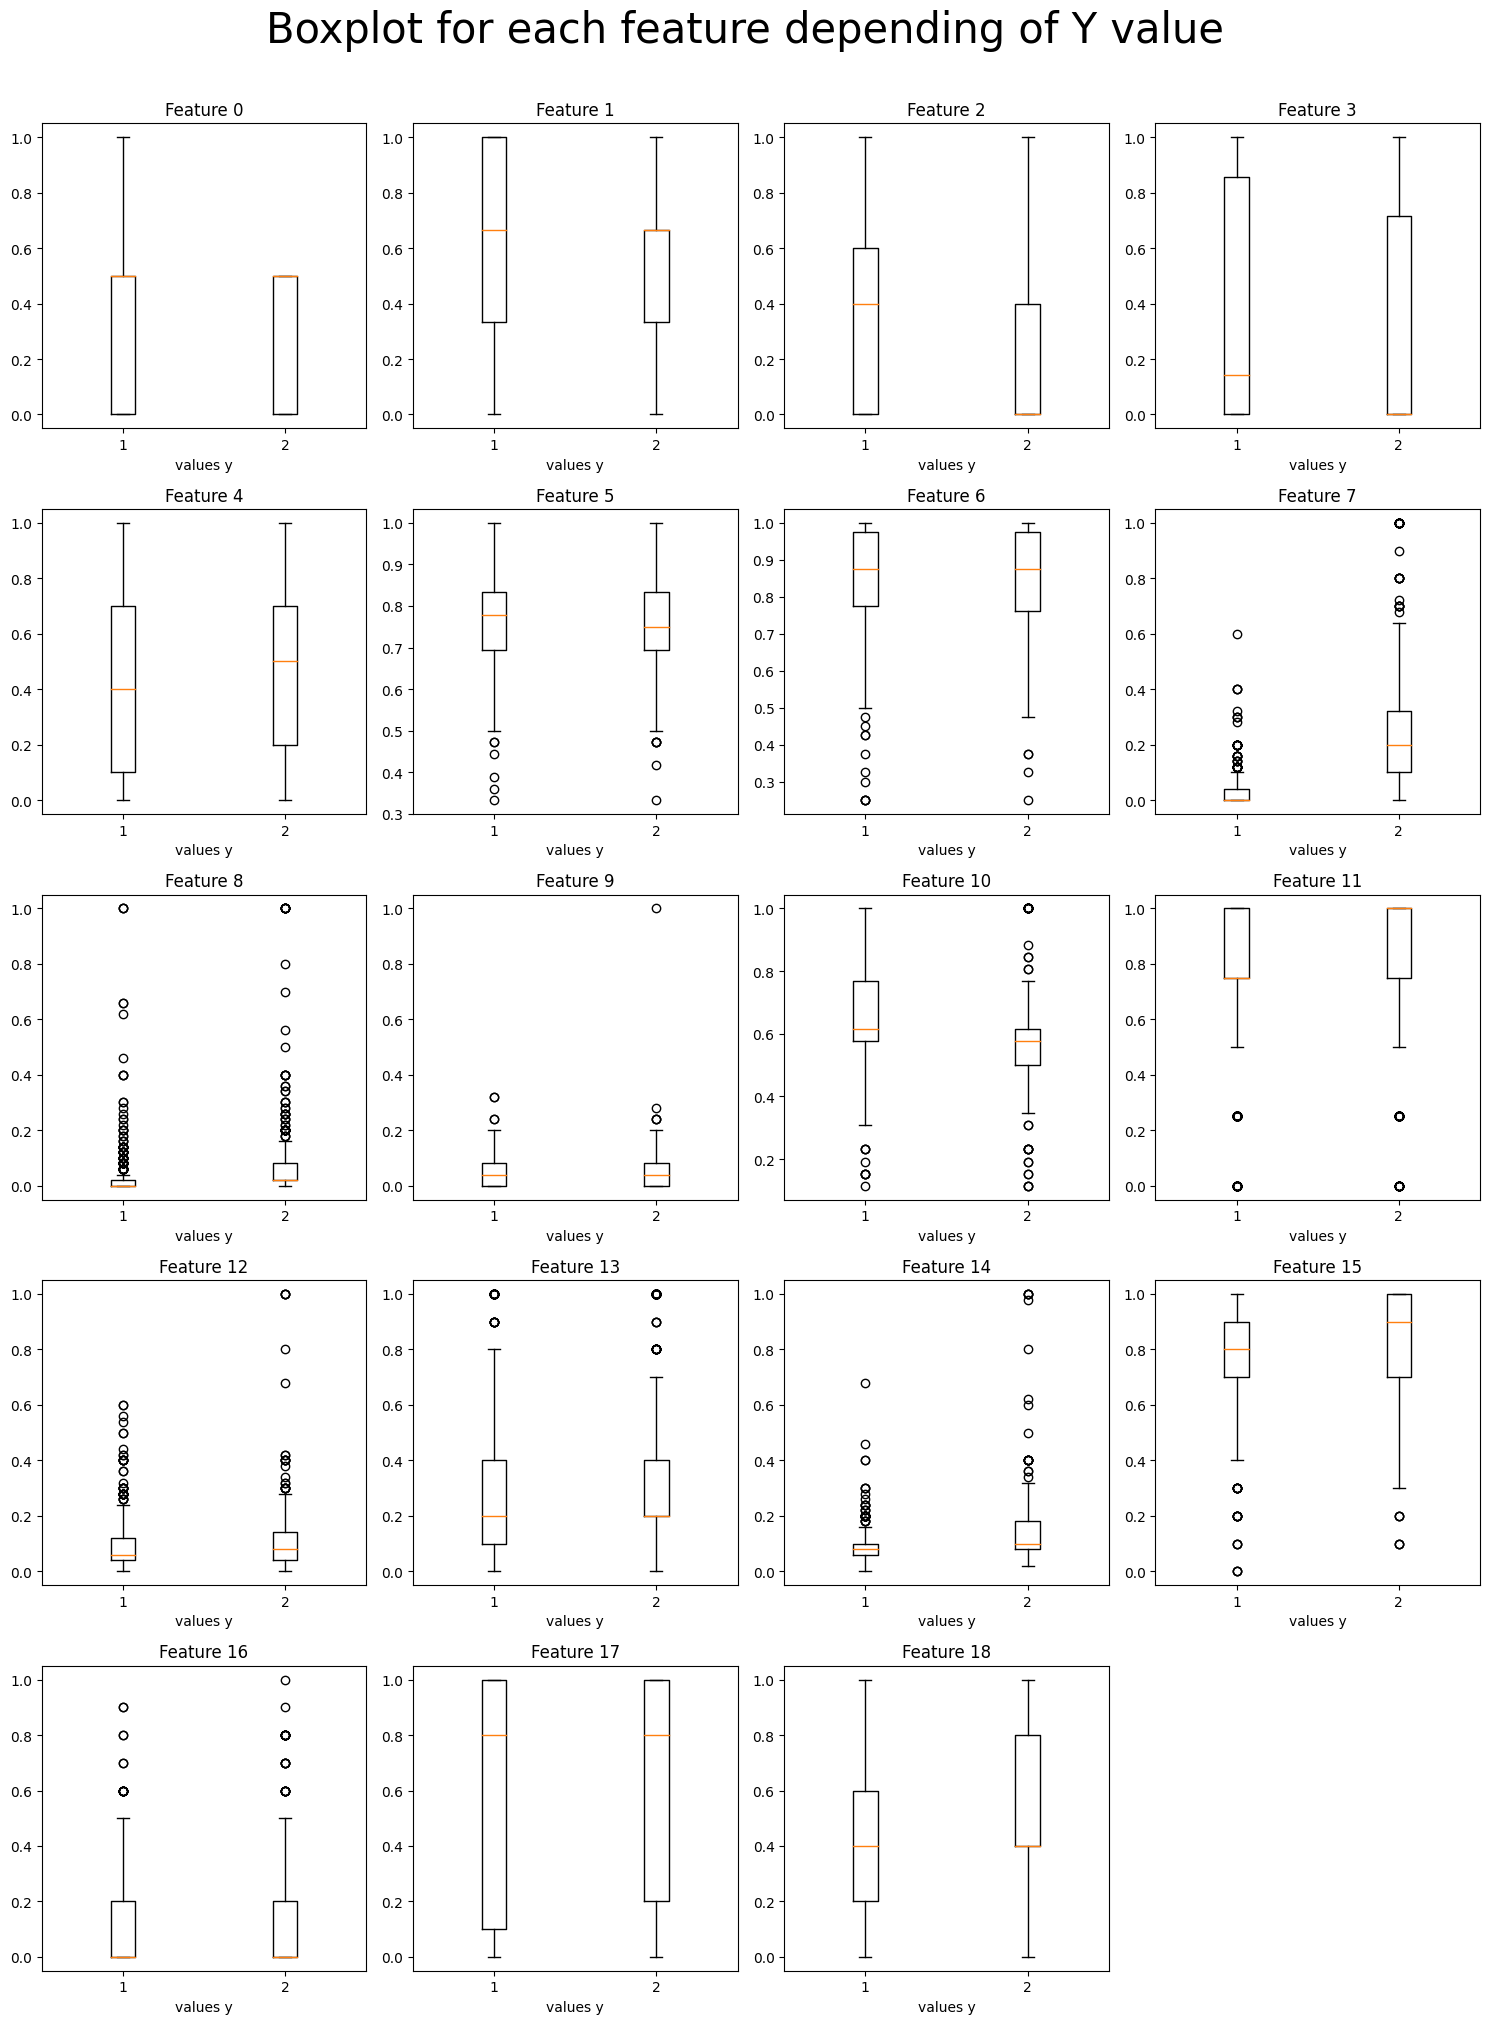

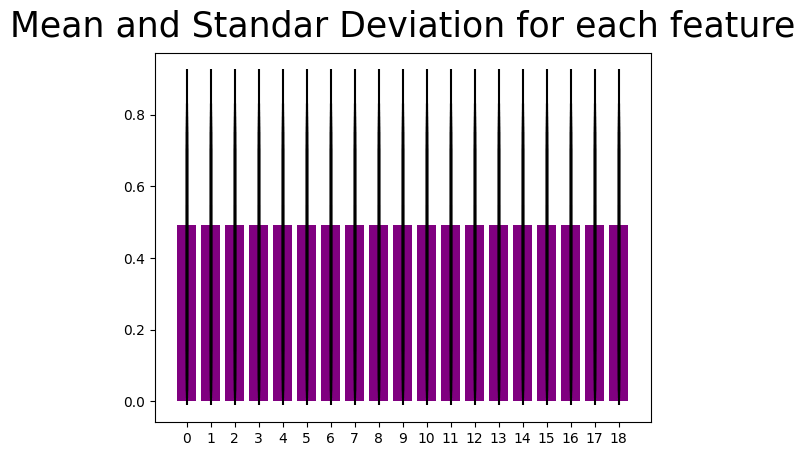

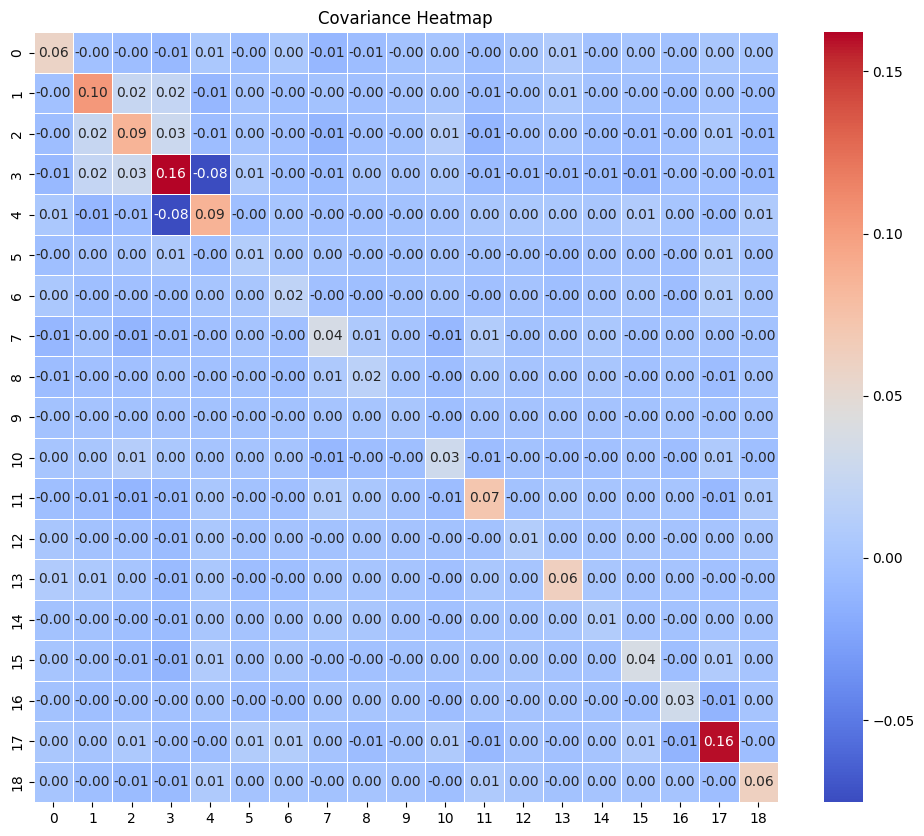

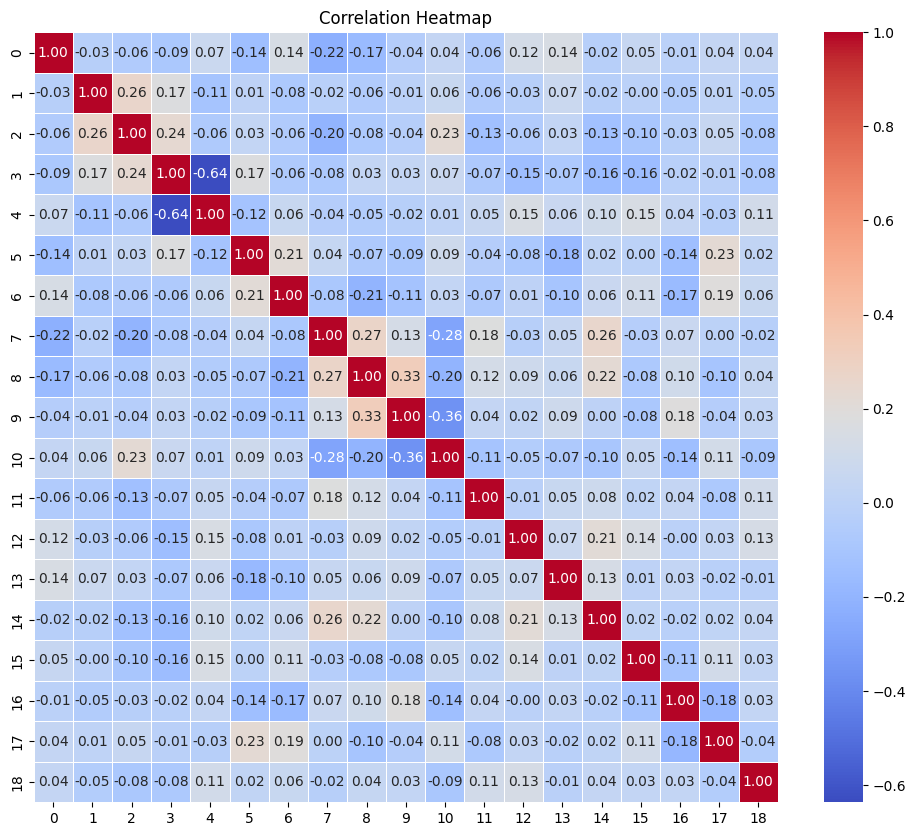

100%|██████████| 2000/2000 [00:00<00:00, 2766.38it/s]
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


TypeError: tight_layout() takes 0 positional arguments but 1 was given

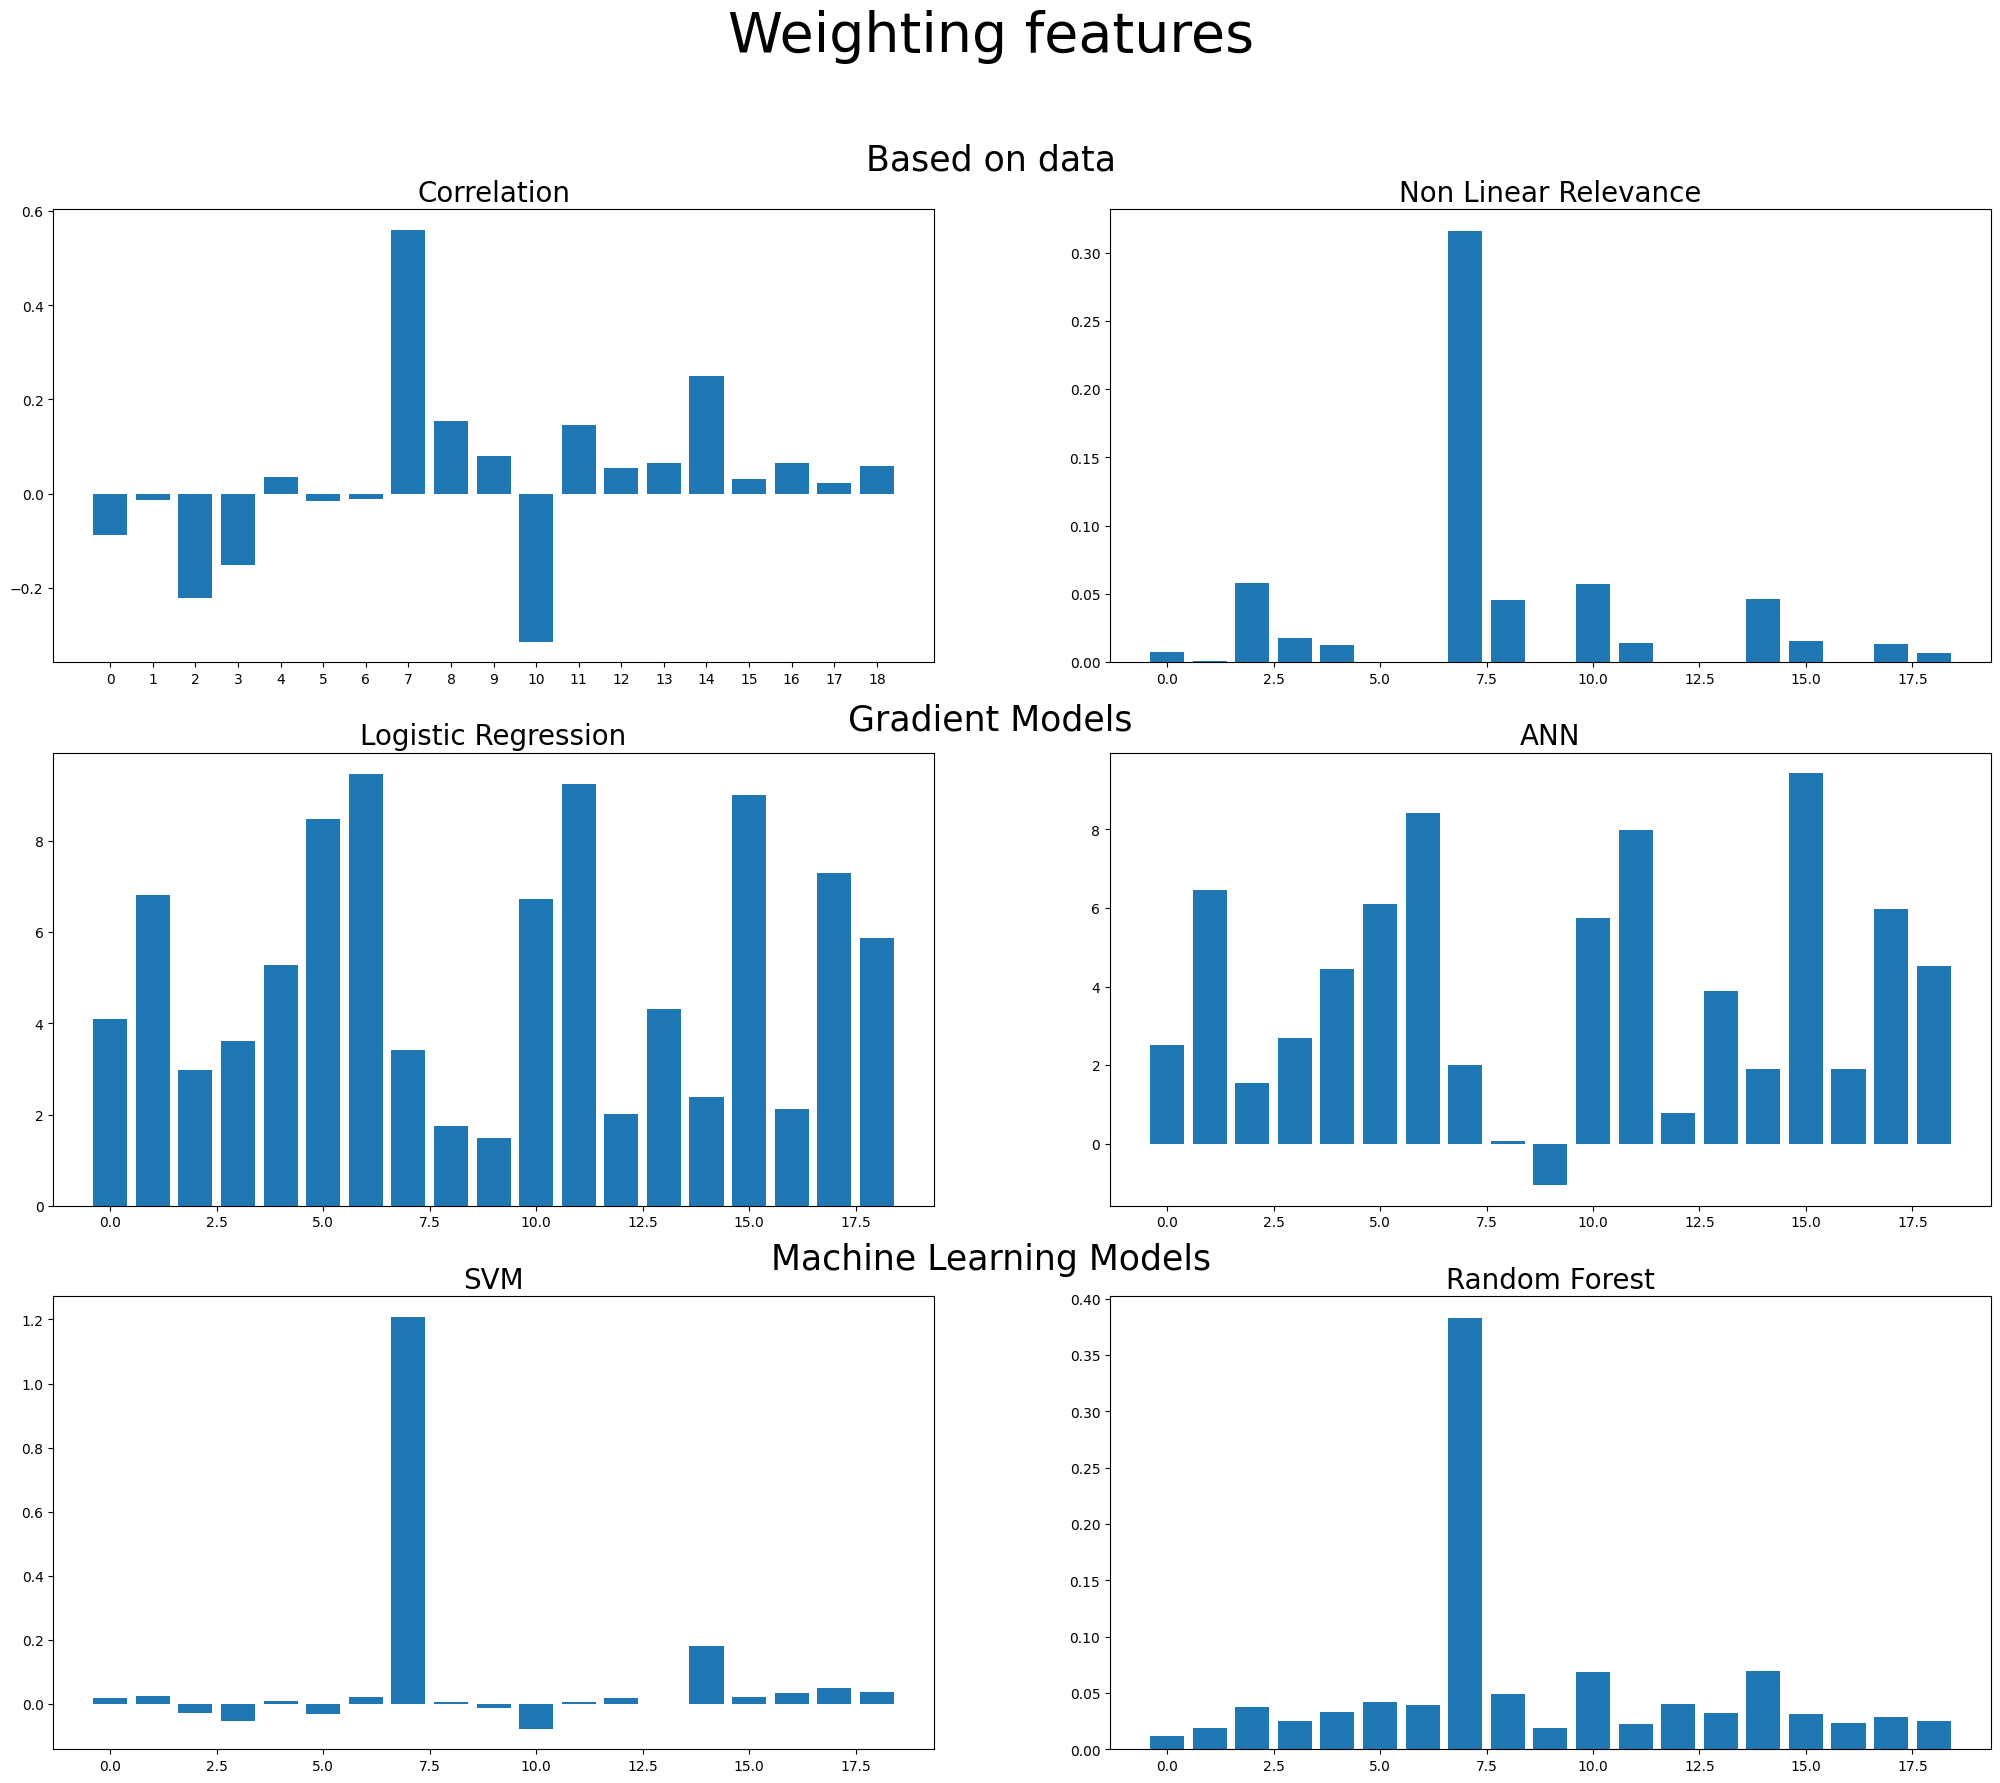

In [102]:
summary_descriptive(x, y)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


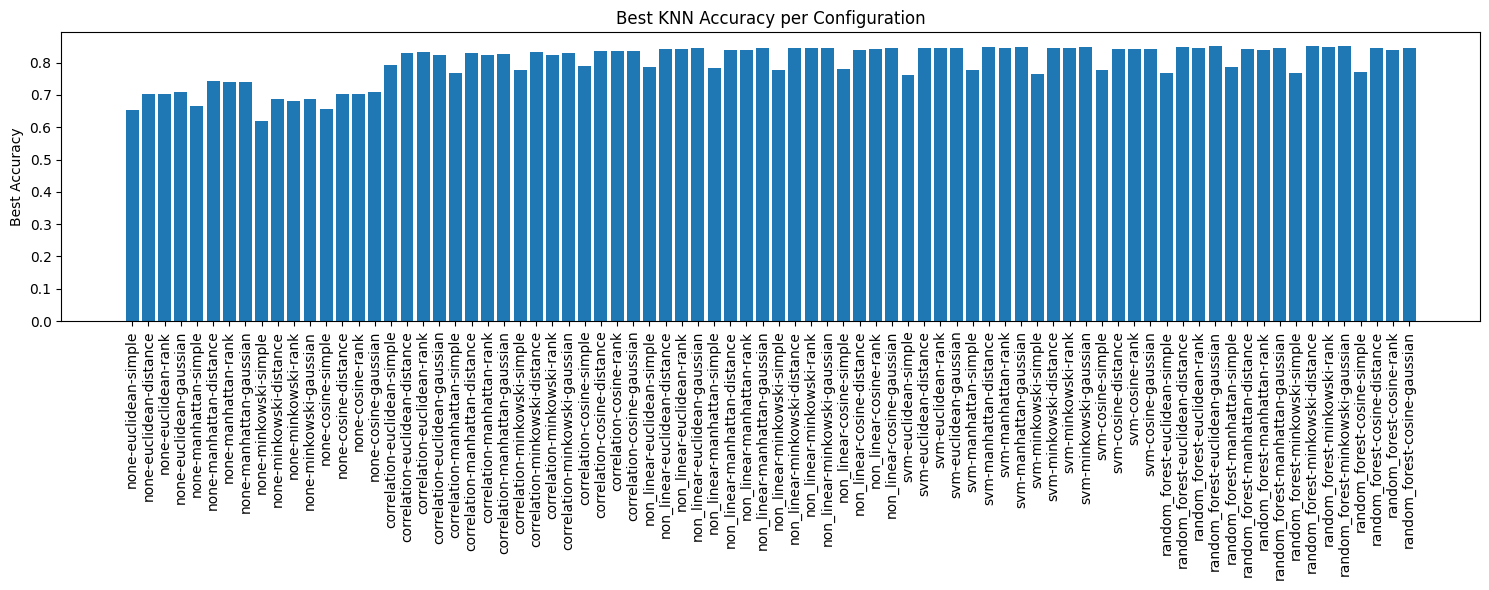

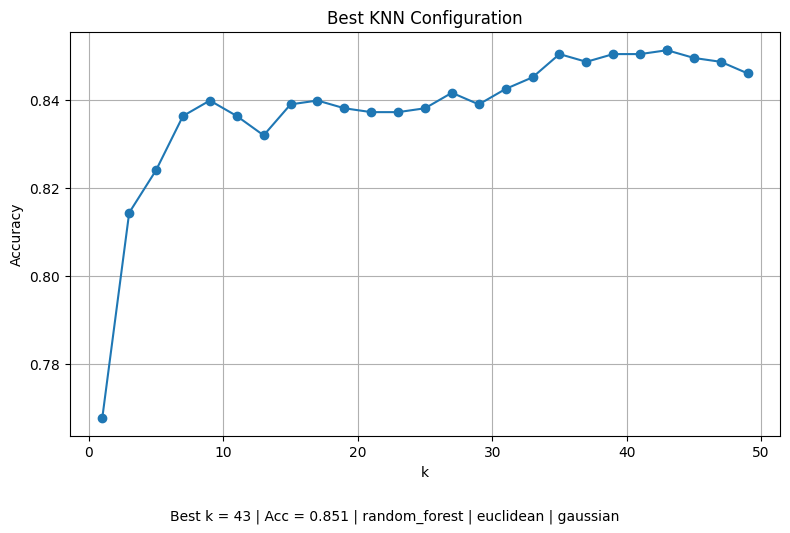

In [110]:
results = run_full_experiment(x, y, 50)
plot_best_accuracy(results)
plot_best_setup(results)